In [1]:
import torch
from gpytorch.distributions.multivariate_normal import MultivariateNormal
from typing import Any, Optional, Union

import gpytorch
torch.set_default_dtype(torch.float64)

In [2]:
from linear_operator.operators import DiagLinearOperator  # or DiagLazyTensor if needed

class NoiseStrategy:
    def get_noise(self, *, noise, task_noises, noise_matrix, mask, train_x, test_x):
        raise NotImplementedError

class ManualNoiseStrategy(NoiseStrategy):
    def __init__(self, manual_noise_values, manual_noise_mask):
        self.manual_noise_values = manual_noise_values  # Shape: (N_train, num_tasks)
        self.manual_noise_mask = manual_noise_mask  # Shape: (N_train, num_tasks)

    def get_noise(self, *, noise, task_noises, noise_matrix, mask, train_x, test_x, num_tasks, is_training):
        """
        Compute the noise matrix to be added to the GP covariance.
        """
        if is_training or (not is_training and test_x is None):
            # TRAINING MODE → Apply manual noise to masked entries
            learned_diag = noise_matrix.diagonal()
            full_mask = mask.flatten()
            manual_noise_flat = self.manual_noise_values.flatten()
            # "True" means the entry should be replaced with manual noise
            combined_noise_diag = torch.where(full_mask, manual_noise_flat, learned_diag)
            return DiagLinearOperator(combined_noise_diag)
        
        else:
            # PREDICTION MODE → No noise on test points
            # Return zero noise added to covariance
            num_points = test_x.size(0)
            return DiagLinearOperator(torch.zeros(num_points * num_tasks, device=test_x.device, dtype=test_x.dtype))



class ManualNoiseLikelihood(gpytorch.likelihoods.MultitaskGaussianLikelihood):
    def set_noise_strategy(self, noise_strategy: NoiseStrategy):
        self.noise_strategy = noise_strategy

    def marginal(self, function_dist, *params, **kwargs):
        mean = function_dist.mean
        covar = function_dist.lazy_covariance_matrix
        
        if not hasattr(self, "noise_strategy"):
            return super().marginal(function_dist, *params, **kwargs)

        mask = kwargs.get("mask", self.noise_strategy.manual_noise_mask)
        train_x = kwargs["train_data"] if "train_data" in kwargs else params[0]
        test_x = kwargs.get("test_data", None)

        # Base learned noise matrix
        # Infer the shape from the function distribution's mean
        num_data = function_dist.mean.numel() // self.num_tasks
        base_noise_matrix = self._shaped_noise_covar((num_data, self.num_tasks), add_noise=self.has_global_noise)

        num_tasks = self.num_tasks

        new_noise = self.noise_strategy.get_noise(
            noise=self.noise,
            task_noises=self.task_noises,
            noise_matrix=base_noise_matrix,
            mask=mask,
            train_x=train_x,
            test_x=test_x,
            num_tasks=num_tasks,
            is_training=self.training
        )

        result_covar = covar + new_noise
        return function_dist.__class__(mean, result_covar)


In [3]:
# https://github.com/cornellius-gp/gpytorch/issues/1881

import math
import gpytorch.constraints
import torch
import gpytorch
import matplotlib.pyplot as plt
from lodegp import LODEGP

with gpytorch.settings.observation_nan_policy("mask"):

    train_x = torch.linspace(0, 1, 4)
    print(train_x)

    train_y = torch.stack([
        torch.exp(0.5*train_x),
        0.5*torch.exp(0.5*train_x),
    ], -1)

    # nan out a few train_y
    train_y[1:, 1] = float('nan')

    # initialize likelihood and model
    
    likelihood = ManualNoiseLikelihood(num_tasks=2, noise_constraint=gpytorch.constraints.GreaterThan(0.0))
    print(likelihood)
    model = LODEGP.LODEGP(train_x, train_y, likelihood, num_tasks=2, verbose=True, ODE_name="Minimal")# base_kernel="Matern_kernel_32")

    manual_noise_values = torch.full_like(train_y, 1e-9)
    manual_noise_values[1, 0] = 1e+5
    print(manual_noise_values)

    manual_noise_mask = torch.full_like(train_y, False, dtype=torch.bool)
    # All datapoints in the first column (i.e. all y_1 values)
    #manual_noise_mask[:, 0] = True
    #manual_noise_mask[0, 1] = True
    #manual_noise_mask[0, 0] = True
    manual_noise_mask[1, 0] = True
    #manual_noise_mask[2, 0] = True
    print(manual_noise_mask)
    manual_noise_strat = ManualNoiseStrategy(manual_noise_values, manual_noise_mask)
    likelihood.set_noise_strategy(manual_noise_strat)

    training_iter = 50

    model.train()
    likelihood.train()

    # Use the adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

    # "Loss" for GPs - the marginal log likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(training_iter):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model(train_x)
        if i == 10:
            print("Output covariance:", likelihood(output, train_data=train_x).covariance_matrix.to_dense().diag())
        # Calc loss and backprop gradients
        loss = -mll(output, train_y, train_data = train_x)
        loss.backward()
        print('Iter %d/%d - Loss: %.3f' % (
            i + 1, training_iter, loss.item()
        ))
        optimizer.step()

tensor([0.0000, 0.3333, 0.6667, 1.0000])
ManualNoiseLikelihood(
  (raw_task_noises_constraint): GreaterThan(0.000E+00)
  (raw_noise_constraint): GreaterThan(0.000E+00)
)
D:[1 0]
V:[ 0  1]
[-1  x]
[[0, 1], [-1, x]]
ParameterDict(
    (signal_variance_1): Parameter containing: [torch.DoubleTensor of size ]
    (lengthscale_1): Parameter containing: [torch.DoubleTensor of size ]
)
tensor([[1.0000e-09, 1.0000e-09],
        [1.0000e+05, 1.0000e-09],
        [1.0000e-09, 1.0000e-09],
        [1.0000e-09, 1.0000e-09]])
tensor([[False, False],
        [ True, False],
        [False, False],
        [False, False]])
Iter 1/50 - Loss: 1.578
Iter 2/50 - Loss: 1.560
Iter 3/50 - Loss: 1.546
Iter 4/50 - Loss: 1.532
Iter 5/50 - Loss: 1.517
Iter 6/50 - Loss: 1.501
Iter 7/50 - Loss: 1.485
Iter 8/50 - Loss: 1.470
Iter 9/50 - Loss: 1.455
Iter 10/50 - Loss: 1.440
Output covariance: tensor([2.1033e+00, 8.6313e-01, 1.0000e+05, 8.6313e-01, 2.1033e+00, 8.6313e-01,
        2.1033e+00, 8.6313e-01], grad_fn=<Dia

tensor([0.0000, 0.3333, 0.6667, 1.0000])


/home/andreas/anaconda3/envs/laplace/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


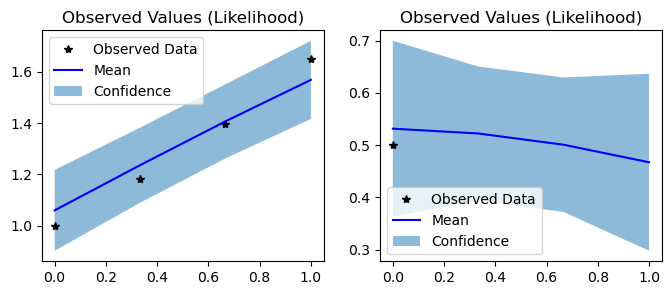

tensor([0.0062, 0.0071, 0.0054, 0.0041, 0.0052, 0.0041, 0.0058, 0.0072])


/home/andreas/anaconda3/envs/laplace/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


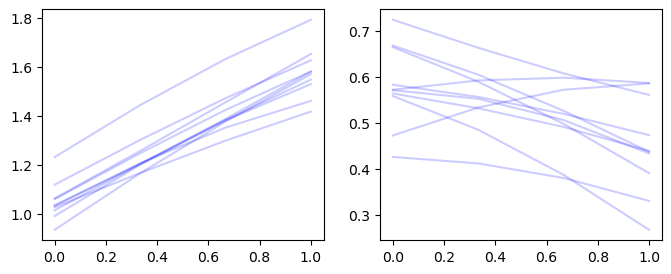

In [6]:
with gpytorch.settings.observation_nan_policy("mask"), gpytorch.settings.cholesky_jitter(0.0):
    # Get into evaluation (predictive posterior) mode
    model.eval()
    likelihood.eval()

    # Initialize plots
    f, (y1_ax, y2_ax) = plt.subplots(1, 2, figsize=(8, 3))

    # Make predictions
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        test_x = torch.linspace(0, 1, 4)
        print(test_x)
        post_mod = model(test_x)
        predictions = likelihood(post_mod, train_data=train_x, test_data=test_x)
        mean = predictions.mean
        lower, upper = predictions.confidence_region()

    # This contains predictions for both tasks, flattened out
    # The first half of the predictions is for the first task
    # The second half is for the second task

    # Plot training data as black stars
    y1_ax.plot(train_x.detach().numpy(), train_y[:, 0].detach().numpy(), 'k*')
    # Predictive mean as blue line
    y1_ax.plot(test_x.numpy(), mean[:, 0].numpy(), 'b')
    # Shade in confidence
    y1_ax.fill_between(test_x.numpy(), lower[:, 0].numpy(), upper[:, 0].numpy(), alpha=0.5)
    y1_ax.legend(['Observed Data', 'Mean', 'Confidence'])
    y1_ax.set_title('Observed Values (Likelihood)')

    # Plot training data as black stars
    y2_ax.plot(train_x.detach().numpy(), train_y[:, 1].detach().numpy(), 'k*')
    # Predictive mean as blue line
    y2_ax.plot(test_x.numpy(), mean[:, 1].numpy(), 'b')
    # Shade in confidence
    y2_ax.fill_between(test_x.numpy(), lower[:, 1].numpy(), upper[:, 1].numpy(), alpha=0.5)
    y2_ax.legend(['Observed Data', 'Mean', 'Confidence'])
    y2_ax.set_title('Observed Values (Likelihood)')

    plt.show()

    print(predictions.covariance_matrix.diag())

    # plot 50 samples from the posterior
    f, (y1_ax, y2_ax) = plt.subplots(1, 2, figsize=(8, 3))
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        samples = post_mod.rsample(torch.Size([10]))
        y1_ax.plot(test_x.numpy(), samples[:, :, 0].numpy().T, 'b', alpha=0.2)
        y2_ax.plot(test_x.numpy(), samples[:, :, 1].numpy().T, 'b', alpha=0.2)  

In [5]:
list(model.named_parameters())

[('likelihood.raw_task_noises',
  Parameter containing:
  tensor([-4.8983, -4.6984], requires_grad=True)),
 ('likelihood.raw_noise',
  Parameter containing:
  tensor([-4.8488], requires_grad=True)),
 ('model_parameters.signal_variance_1',
  Parameter containing:
  tensor(0.5041, requires_grad=True)),
 ('model_parameters.lengthscale_1',
  Parameter containing:
  tensor(1.3176, requires_grad=True))]